In [280]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor



%matplotlib inline

In [281]:
df_train = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

df_train.shape
test_ids = df_test['Id']

df_train.drop(['Id'], axis=1, inplace=True)
df_test.drop(['Id'], axis=1, inplace=True)

In [282]:
df_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


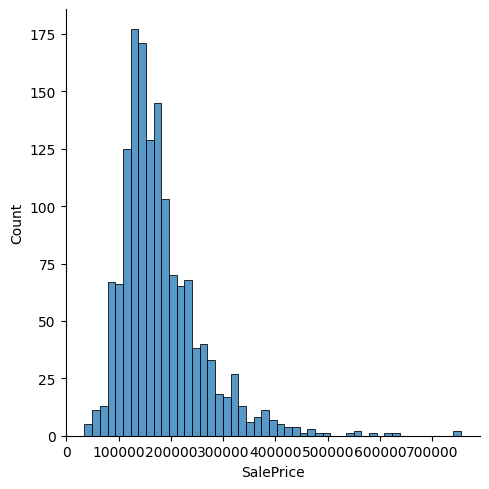

In [283]:
sns.displot(df_train["SalePrice"])

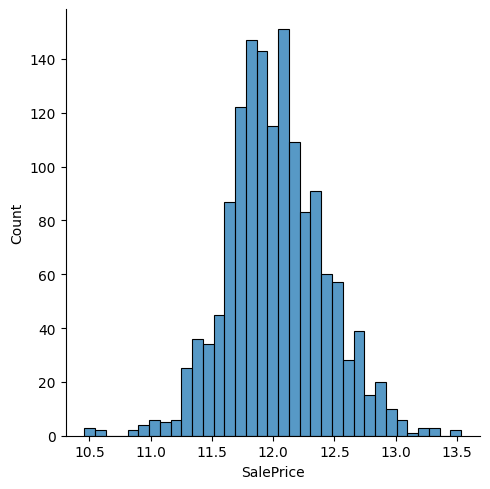

In [284]:
df_train["SalePrice"] = np.log1p(df_train["SalePrice"])
sns.displot(df_train["SalePrice"])

In [285]:
y_train = df_train['SalePrice']
df_train.drop("SalePrice", axis=1, inplace=True)



all_data = pd.concat([df_train, df_test])
all_data = all_data.drop('Utilities', axis=1)

fill_with_None = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'MasVnrType' ,
                   'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond' , 'BsmtQual', 
                   'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
                 ]

all_data[fill_with_None] = all_data[fill_with_None].fillna("None")


fill_with_zero = ['GarageYrBlt', 'GarageArea', 'GarageCars',
                  'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 
                  'BsmtFullBath', 'BsmtHalfBath' , 'MasVnrArea'
                 ]

all_data[fill_with_zero] = all_data[fill_with_zero].fillna(0)


all_data["LotFrontage"] = all_data.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

fill_with_mods = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd', 'SaleType', 'Functional']
all_data[fill_with_mods] = all_data[fill_with_mods].fillna(all_data[fill_with_mods].mode().iloc[0]) 

In [286]:
all_data = pd.get_dummies(all_data)

In [287]:


X_train = all_data.iloc[:len(y_train)]

X_test = all_data.iloc[len(y_train):]

xgb = XGBRegressor(
                    learning_rate=0.01, 
                    n_estimators=3000,  
                    random_state=42 , 
                    )

lgb = LGBMRegressor(
                    objective='regression' , 
                    learning_rate=0.02 , 
                    n_estimators=720 , 
                    max_depth=4,
                    num_leaves=15,
                    random_state=42, 
                    )

xgb.fit(X_train, y_train)
lgb.fit(X_train , y_train)

xgbpredict = xgb.predict(X_test)
lgbpredict = lgb.predict(X_test)

finalpredictboth = np.expm1 (0.6*xgbpredict + 0.4*lgbpredict)

submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': finalpredictboth
})

submission.to_csv('submission.csv', index=False)